# SegFormer (MiT-B2)

Modelo U-Net con encoder ResNet101 para segmentar construcciones en imágenes satelitales (1  metro de resolcuion espacial). El modelo arranca con pesos preentrenados en ImageNet y se entrena combinando Dice y Focal Loss, con AdamW como optimizador y un scheduler CosineAnnealingLR. La evaluación va más allá de las métricas habituales de segmentación: también se aplica Test-Time Augmentation (TTA) y se busca el umbral de decisión óptimo. Además, el cuaderno permite hacer inferencia sobre imágenes GeoTIFF propias, conservando su referencia espacial, y genera visualizaciones que incluyen la imagen original, la máscara real, la predicción, el mapa de calor de probabilidad y la superposición.


In [1]:
# Librerias entorno

import sys
import subprocess
import importlib
import importlib.metadata as metadata

PAQUETES_REQUERIDOS = {
    "segmentation-models-pytorch": ("segmentation_models_pytorch", "0.4.0"),
    "albumentations": ("albumentations", "1.4.24"),
}

def asegurar_paquete(nombre_paquete, nombre_import, version_objetivo):
    try:
        version_actual = metadata.version(nombre_paquete)
    except metadata.PackageNotFoundError:
        version_actual = None

    if version_actual != version_objetivo:
        print(f"Instalando {nombre_paquete}=={version_objetivo} ...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q",
            "--disable-pip-version-check",
            f"{nombre_paquete}=={version_objetivo}",
        ])

    importlib.invalidate_caches()

    try:
        importlib.import_module(nombre_import)
    except Exception as exc:
        raise RuntimeError(
            f"No fue posible importar {nombre_import}. "
            f"En Kaggle verifica que Internet esté habilitado para instalar paquetes. "
            f"Error original: {type(exc).__name__}: {exc}"
        ) from exc

for paquete, (modulo, version) in PAQUETES_REQUERIDOS.items():
    asegurar_paquete(paquete, modulo, version)



/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
# Librerias
import os
import sys
import random
import time
import math
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import cv2
import rasterio
from rasterio.windows import Window
from rasterio.transform import Affine
from PIL import Image

from tqdm.auto import tqdm
import albumentations as album

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
from sklearn.metrics import confusion_matrix

# Semilla
SEMILLA = 42
def fijar_semilla(semilla=SEMILLA):
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(semilla)
        torch.cuda.manual_seed_all(semilla)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fijar_semilla(SEMILLA)

DISPOSITIVO = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# Configuración SegFormer Experimento 1

ARCHITECTURE = "SegFormer"
ENCODER = "mit_b2"
ENCODER_WEIGHTS = "imagenet"
CODIFICADOR = ENCODER
PESOS_CODIFICADOR = ENCODER_WEIGHTS

CLASES = ["background", "building"]
clases_seleccionadas = CLASES
NUM_CLASES = 2
TAMANO_IMAGEN = 256
IMAGE_SIZE = TAMANO_IMAGEN
BATCH_SIZE = 4
NUM_WORKERS = 0
EPOCAS = 80
EPOCHS = EPOCAS
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
T_MAX = 80
T_MAX_SCHEDULER = T_MAX

# Early stopping
PACIENCIA_EARLY_STOPPING = 15
MEJORES_K_CHECKPOINTS = 3

SESGO_BUILDING_TRAIN = 0.0
INTENTOS_CROP_SESGADO = 5
OBJETIVO_IOU_BUILDING = "max"
OBJETIVO_PRECISION_CALIBRACION = 0.85

THRESHOLDS_VALIDACION = [0.30, 0.35, 0.40, 0.45, 0.50,
                         0.55, 0.60, 0.65, 0.70]

print("CONFIGURACIÓN")
print(f"PyTorch: {torch.__version__}")
print(f"SMP: {smp.__version__}")
print(f"Albumentations: {album.__version__}")
print(f"Modelo: {ARCHITECTURE} + {ENCODER}")
print(f"Tile: {TAMANO_IMAGEN}x{TAMANO_IMAGEN}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Épocas máximas: {EPOCAS}")
print(f"Learning rate inicial: {LEARNING_RATE}")
print(f"T_max scheduler: {T_MAX_SCHEDULER}")
print(f"Paciencia early stopping: {PACIENCIA_EARLY_STOPPING}")
print(f"Semilla: {SEMILLA}")
print(f"Dispositivo: {DISPOSITIVO}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


# Comprobación de API
APIS_REQUERIDAS = {
    "smp.Segformer": hasattr(smp, "Segformer"),
    "smp.encoders.get_preprocessing_fn": hasattr(smp.encoders, "get_preprocessing_fn"),
    "encoder mit_b2": "mit_b2" in smp.encoders.get_encoder_names(),
    "smp.losses.DiceLoss": hasattr(smp.losses, "DiceLoss"),
    "smp.losses.FocalLoss": hasattr(smp.losses, "FocalLoss"),
    "smp.metrics.get_stats": hasattr(smp.metrics, "get_stats"),
    "smp.metrics.iou_score": hasattr(smp.metrics, "iou_score"),
    "smp.metrics.f1_score": hasattr(smp.metrics, "f1_score"),
    "smp.metrics.precision": hasattr(smp.metrics, "precision"),
    "smp.metrics.recall": hasattr(smp.metrics, "recall"),
    "smp.metrics.accuracy": hasattr(smp.metrics, "accuracy"),
    "album.Compose": hasattr(album, "Compose"),
    "album.OneOf": hasattr(album, "OneOf"),
    "album.HorizontalFlip": hasattr(album, "HorizontalFlip"),
    "album.VerticalFlip": hasattr(album, "VerticalFlip"),
    "album.RandomRotate90": hasattr(album, "RandomRotate90"),
    "album.RandomBrightnessContrast": hasattr(album, "RandomBrightnessContrast"),
    "album.Lambda": hasattr(album, "Lambda"),
    "album.PadIfNeeded": hasattr(album, "PadIfNeeded"),
}

APIS_FALTANTES = [nombre for nombre, existe in APIS_REQUERIDAS.items() if not existe]
if APIS_FALTANTES:
    raise ImportError(
        "Faltan APIs requeridas: " + ", ".join(APIS_FALTANTES)
    )

print("Compatibilidad de APIs SMP/Albumentations: OK")

LIBRERIAS_REQUERIDAS = {
    "numpy": np,
    "pandas": pd,
    "matplotlib": plt,
    "opencv": cv2,
    "rasterio": rasterio,
    "albumentations": album,
    "torch": torch,
    "segmentation_models_pytorch": smp,
    "sklearn": __import__("sklearn"),
    "PIL": Image,
    "tqdm": tqdm,
}

print("Librerías requeridas: OK")

assert hasattr(smp, "Segformer"), "API de modelo no disponible: smp.Segformer"
assert "mit_b2" in smp.encoders.get_encoder_names(), "Encoder no disponible: mit_b2"
assert NUM_WORKERS == 0, "NUM_WORKERS debe ser 0 para este experimento."


CONFIGURACIÓN
PyTorch: 2.10.0+cu128
SMP: 0.4.0
Albumentations: 1.4.24
Modelo: SegFormer + mit_b2
Tile: 256x256
Batch size: 4
Épocas máximas: 80
Learning rate inicial: 0.0001
T_max scheduler: 80
Paciencia early stopping: 15
Semilla: 42
Dispositivo: cuda
GPU: Tesla T4
Compatibilidad de APIs SMP/Albumentations: OK
Librerías requeridas: OK


In [3]:
# VALIDACIÓN DE ARQUITECTURA
assert hasattr(smp, "Segformer"), (
    "La instalación actual no expone smp.Segformer."
)
assert CODIFICADOR == "mit_b2", (
    f"Encoder configurado incorrectamente: {CODIFICADOR}; se esperaba mit_b2"
)
assert CODIFICADOR in smp.encoders.get_encoder_names(), (
    f"El encoder {CODIFICADOR} no está disponible en la instalación."
)

APIS_MODELO = {
    "smp.Segformer": hasattr(smp, "Segformer"),
    "smp.encoders.get_preprocessing_fn": hasattr(smp.encoders, "get_preprocessing_fn"),
    "smp.losses.DiceLoss": hasattr(smp.losses, "DiceLoss"),
    "smp.losses.FocalLoss": hasattr(smp.losses, "FocalLoss"),
    "smp.metrics.get_stats": hasattr(smp.metrics, "get_stats"),
    "smp.metrics.accuracy": hasattr(smp.metrics, "accuracy"),
    "smp.metrics.iou_score": hasattr(smp.metrics, "iou_score"),
    "smp.metrics.f1_score": hasattr(smp.metrics, "f1_score"),
    "smp.metrics.precision": hasattr(smp.metrics, "precision"),
    "smp.metrics.recall": hasattr(smp.metrics, "recall"),
}

APIS_AUGMENTATION = {
    "album.Compose": hasattr(album, "Compose"),
    "album.OneOf": hasattr(album, "OneOf"),
    "album.HorizontalFlip": hasattr(album, "HorizontalFlip"),
    "album.VerticalFlip": hasattr(album, "VerticalFlip"),
    "album.RandomRotate90": hasattr(album, "RandomRotate90"),
    "album.RandomBrightnessContrast": hasattr(album, "RandomBrightnessContrast"),
    "album.Lambda": hasattr(album, "Lambda"),
    "album.PadIfNeeded": hasattr(album, "PadIfNeeded"),
}

faltantes = [
    nombre for nombre, disponible in {**APIS_MODELO, **APIS_AUGMENTATION}.items()
    if not disponible
]
if faltantes:
    raise ImportError("APIs requeridas no disponibles: " + ", ".join(faltantes))

print("Modelo: smp.Segformer -> OK")
print("Encoder: MiT-B2 -> OK")
print("APIs SMP y Albumentations utilizadas -> OK")


Modelo: smp.Segformer -> OK
Encoder: MiT-B2 -> OK
APIs SMP y Albumentations utilizadas -> OK


In [4]:
# Dataset Original Massachusetts
CARPETA_DATOS = '/kaggle/input/datasets/balraj98/massachusetts-buildings-dataset/tiff'

ruta_train_x = os.path.join(CARPETA_DATOS, 'train')
ruta_train_y = os.path.join(CARPETA_DATOS, 'train_labels')

ruta_val_x = os.path.join(CARPETA_DATOS, 'val')
ruta_val_y = os.path.join(CARPETA_DATOS, 'val_labels')

ruta_test_x = os.path.join(CARPETA_DATOS, 'test')
ruta_test_y = os.path.join(CARPETA_DATOS, 'test_labels')

clases_seleccionadas = ['background', 'building']
rgb_clases_seleccionadas = np.array([[0, 0, 0], [255, 255, 255]])

def contar_archivos(carpeta):
    return len([f for f in os.listdir(carpeta) if not f.startswith('.')])

print('Dataset: Massachusetts Buildings Dataset - balraj98')
print('Clases seleccionadas:', clases_seleccionadas)
print('Paleta (visualizacion):', rgb_clases_seleccionadas.tolist())
print()
print(f'Train      : {contar_archivos(ruta_train_x)} imagenes | {contar_archivos(ruta_train_y)} mascaras')
print(f'Validation : {contar_archivos(ruta_val_x)} imagenes | {contar_archivos(ruta_val_y)} mascaras')
print(f'Test       : {contar_archivos(ruta_test_x)} imagenes | {contar_archivos(ruta_test_y)} mascaras')


Dataset: Massachusetts Buildings Dataset - balraj98
Clases seleccionadas: ['background', 'building']
Paleta (visualizacion): [[0, 0, 0], [255, 255, 255]]

Train      : 137 imagenes | 137 mascaras
Validation : 4 imagenes | 4 mascaras
Test       : 10 imagenes | 10 mascaras


In [5]:
# Validacion de dataset
import hashlib

def calcular_hash_archivo(ruta):
    with open(ruta, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def hashes_de_carpeta(carpeta):
    hashes = {}
    for archivo in tqdm(sorted(os.listdir(carpeta)), desc=f'hashing {os.path.basename(carpeta)}'):
        ruta = os.path.join(carpeta, archivo)
        hashes[archivo] = calcular_hash_archivo(ruta)
    return hashes


# Conteo de parches por particion
archivos_train = sorted(os.listdir(ruta_train_x))
archivos_val = sorted(os.listdir(ruta_val_x))
archivos_test = sorted(os.listdir(ruta_test_x))

print("1. CONTEO DE PARCHES POR PARTICION")
print(f"Train: {len(archivos_train)} parches")
print(f"Val  : {len(archivos_val)} parches  (antes del tileado: 4 imagenes completas)")
print(f"Test : {len(archivos_test)} parches  (antes del tileado: 10 imagenes completas)")

print("*" * 30)
# Fuga por nombre de archivo
set_train_nombres = set(archivos_train)
set_val_nombres = set(archivos_val)
set_test_nombres = set(archivos_test)
print("*" * 30)
print("2. SOLAPE DE NOMBRES DE ARCHIVO ENTRE PARTICIONES")
print(f"Train ^ Val  : {len(set_train_nombres & set_val_nombres)} nombres en comun")
print(f"Train ^ Test : {len(set_train_nombres & set_test_nombres)} nombres en comun")
print(f"Val ^ Test   : {len(set_val_nombres & set_test_nombres)} nombres en comun")
print("*" * 30)
print("3. FUGA DE DATOS POR CONTENIDO (hash MD5 de cada imagen)")
hashes_train = hashes_de_carpeta(ruta_train_x)
hashes_val = hashes_de_carpeta(ruta_val_x)
hashes_test = hashes_de_carpeta(ruta_test_x)
print("*" * 30)
valores_train = set(hashes_train.values())
valores_val = set(hashes_val.values())
valores_test = set(hashes_test.values())

interseccion_train_val = valores_train & valores_val
interseccion_train_test = valores_train & valores_test
interseccion_val_test = valores_val & valores_test

print(f"Imagenes identicas Train-Val : {len(interseccion_train_val)}")
print(f"Imagenes identicas Train-Test: {len(interseccion_train_test)}")
print(f"Imagenes identicas Val-Test  : {len(interseccion_val_test)}")

if interseccion_train_val or interseccion_train_test or interseccion_val_test:
    print("\nALERTA: se detectaron imagenes IDENTICAS en mas de una particion.")
    print("        Esto es fuga de datos real -- NO sigas con el entrenamiento sin revisar el proceso de tileado. Puede ser una imagen origen que se filtro a dos particiones, o un error al copiar los archivos.")
else:
    print("\nOK: no se detectaron imagenes identicas entre particiones.")


# Balance de clases por particion
def porcentaje_building_muestra(carpeta_mascaras, n_muestra=200):
    archivos = sorted(os.listdir(carpeta_mascaras))
    muestra = archivos[:min(n_muestra, len(archivos))]
    porcentajes = []
    for archivo in muestra:
        mascara = cv2.imread(os.path.join(carpeta_mascaras, archivo), cv2.IMREAD_GRAYSCALE)
        porcentajes.append((mascara > 127).mean())
    return float(np.mean(porcentajes) * 100)
print("*" * 30)
print("4. BALANCE DE CLASES (% pixeles building, muestra de hasta 200 parches)")
print(f"Train: {porcentaje_building_muestra(ruta_train_y):.2f} %")
print(f"Val  : {porcentaje_building_muestra(ruta_val_y):.2f} %")
print(f"Test : {porcentaje_building_muestra(ruta_test_y):.2f} %")

print("*" * 30)
# Dimensiones y valores de mascara 
def dimensiones_muestra(carpeta, n=50):
    archivos = sorted(os.listdir(carpeta))[:n]
    formas = set()
    for archivo in archivos:
        img = cv2.imread(os.path.join(carpeta, archivo))
        formas.add(img.shape[:2])
    return formas

def valores_unicos_mascara(carpeta_mascaras, n=50):
    archivos = sorted(os.listdir(carpeta_mascaras))[:n]
    valores = set()
    for archivo in archivos:
        m = cv2.imread(os.path.join(carpeta_mascaras, archivo), cv2.IMREAD_GRAYSCALE)
        valores.update(np.unique(m).tolist())
    return sorted(valores)
print("*" * 30)
print("5. DIMENSIONES Y VALORES DE MASCARA (muestra de 50 por particion)")
print("Dimensiones train:", dimensiones_muestra(ruta_train_x))
print("Dimensiones val  :", dimensiones_muestra(ruta_val_x))
print("Dimensiones test :", dimensiones_muestra(ruta_test_x))
print("Valores mascara train:", valores_unicos_mascara(ruta_train_y))
print("Valores mascara val  :", valores_unicos_mascara(ruta_val_y))
print("Valores mascara test :", valores_unicos_mascara(ruta_test_y))


1. CONTEO DE PARCHES POR PARTICION
Train: 137 parches
Val  : 4 parches  (antes del tileado: 4 imagenes completas)
Test : 10 parches  (antes del tileado: 10 imagenes completas)
******************************
******************************
2. SOLAPE DE NOMBRES DE ARCHIVO ENTRE PARTICIONES
Train ^ Val  : 0 nombres en comun
Train ^ Test : 0 nombres en comun
Val ^ Test   : 0 nombres en comun
******************************
3. FUGA DE DATOS POR CONTENIDO (hash MD5 de cada imagen)


hashing train:   0%|          | 0/137 [00:00<?, ?it/s]

hashing val:   0%|          | 0/4 [00:00<?, ?it/s]

hashing test:   0%|          | 0/10 [00:00<?, ?it/s]

******************************
Imagenes identicas Train-Val : 0
Imagenes identicas Train-Test: 0
Imagenes identicas Val-Test  : 0

OK: no se detectaron imagenes identicas entre particiones.
******************************
4. BALANCE DE CLASES (% pixeles building, muestra de hasta 200 parches)
Train: 13.20 %
Val  : 10.88 %
Test : 18.61 %
******************************
******************************
5. DIMENSIONES Y VALORES DE MASCARA (muestra de 50 por particion)


[ WARN:0@23.568] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@23.568] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@23.568] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@23.568] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@23.568] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@23.586] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@23.586] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@23.586] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered


Dimensiones train: {(1500, 1500)}
Dimensiones val  : {(1500, 1500)}
Dimensiones test : {(1500, 1500)}
Valores mascara train: [0, 255]
Valores mascara val  : [0, 255]
Valores mascara test : [0, 255]


In [6]:
def visualizar(**imagenes):
    n_imagenes = len(imagenes)
    plt.figure(figsize=(20, 8))
    for idx, (nombre, imagen) in enumerate(imagenes.items()):
        plt.subplot(1, n_imagenes, idx + 1)
        plt.xticks([]); plt.yticks([])
        plt.title(nombre.replace('_', ' ').title(), fontsize=20)
        plt.imshow(imagen)
    plt.show()

def codificar_one_hot_binaria(mascara_gris, umbral=127):
    """Convierte una mascara en escala de grises (0/255) en one-hot [background, building].

    Reemplaza a la version anterior basada en 'codificar_one_hot' + RGB, para trabajar con las máscaras binarias del Massachusetts Buildings Dataset.
    """
    building = (mascara_gris > umbral)
    background = ~building
    return np.stack([background, building], axis=-1)


def decodificar_one_hot(imagen):
    return np.argmax(imagen, axis=-1)


def colorear_segmentacion(imagen, valores_clase):
    return np.array(valores_clase)[imagen.astype(int)]


def recorte_sesgado_building(imagen, mascara, tam=256, intentos=5,
                                prob_sesgo=0.7, indice_building=1):
    """Recorta la imagen a un tamaño de 256 × 256 píxeles.
    
    *Train: selecciona recortes que tengan mayor probabilidad de incluir edificios.
    *Validation y test: utiliza un recorte centrado para mantener un proceso fijo y reproducible.
    """
    h, w = imagen.shape[:2]

    if h <= tam and w <= tam:
        return imagen[:tam, :tam], mascara[:tam, :tam]

    if prob_sesgo <= 0:
        y = max((h - tam) // 2, 0)
        x = max((w - tam) // 2, 0)
        return imagen[y:y + tam, x:x + tam], mascara[y:y + tam, x:x + tam]

    candidatos = []
    for _ in range(max(intentos, 1)):
        y = random.randint(0, max(h - tam, 0))
        x = random.randint(0, max(w - tam, 0))
        crop_mascara = mascara[y:y + tam, x:x + tam]
        porcentaje_building = crop_mascara[..., indice_building].mean()
        candidatos.append((porcentaje_building, y, x))

    if random.random() < prob_sesgo:
        candidatos.sort(key=lambda c: c[0], reverse=True)
        _, y, x = candidatos[0]
    else:
        _, y, x = random.choice(candidatos)

    return imagen[y:y + tam, x:x + tam], mascara[y:y + tam, x:x + tam]

class DatasetEdificios(torch.utils.data.Dataset):
    def __init__(self, carpeta_imagenes, carpeta_mascaras, rgb_clases=None,
                 tam_crop=512, sesgo_building=0.0, intentos_crop=5,
                 aumentacion=None, preprocesamiento=None):
        self.rutas_imagenes = [os.path.join(carpeta_imagenes, f) for f in sorted(os.listdir(carpeta_imagenes))]
        self.rutas_mascaras = [os.path.join(carpeta_mascaras, f) for f in sorted(os.listdir(carpeta_mascaras))]
        assert len(self.rutas_imagenes) == len(self.rutas_mascaras), (
            f"Numero de imagenes ({len(self.rutas_imagenes)}) y mascaras "
            f"({len(self.rutas_mascaras)}) no coincide en {carpeta_imagenes}"
        )
        self.rgb_clases = rgb_clases
        self.tam_crop = tam_crop
        self.sesgo_building = sesgo_building  # 0.0 en val/test = recorte aleatorio simple
        self.intentos_crop = intentos_crop
        self.aumentacion = aumentacion
        self.preprocesamiento = preprocesamiento

    def __getitem__(self, i):
        imagen = cv2.cvtColor(cv2.imread(self.rutas_imagenes[i]), cv2.COLOR_BGR2RGB)
        mascara_gris = cv2.imread(self.rutas_mascaras[i], cv2.IMREAD_GRAYSCALE)

        if imagen is None:
            raise FileNotFoundError(f"No se pudo leer la imagen: {self.rutas_imagenes[i]}")
        if mascara_gris is None:
            raise FileNotFoundError(f"No se pudo leer la mascara: {self.rutas_mascaras[i]}")

        # Las imágenes originales de Massachusetts son 1500x1500.
        # Se mantiene la resolución original y se extrae un crop de 256x256.
        mascara = codificar_one_hot_binaria(mascara_gris).astype('float32')

        imagen, mascara = recorte_sesgado_building(
            imagen, mascara, tam=self.tam_crop,
            intentos=self.intentos_crop, prob_sesgo=self.sesgo_building,
        )

        if self.aumentacion:
            muestra = self.aumentacion(image=imagen, mask=mascara)
            imagen, mascara = muestra['image'], muestra['mask']
        if self.preprocesamiento:
            muestra = self.preprocesamiento(image=imagen, mask=mascara)
            imagen, mascara = muestra['image'], muestra['mask']

        return imagen, mascara

    def __len__(self):
        return len(self.rutas_imagenes)


In [7]:
# Preprocesamiento y aumentos para adaptar las imágenes al MiT-B2 y al formato de PyTorch.

funcion_preprocesamiento = smp.encoders.get_preprocessing_fn(CODIFICADOR, PESOS_CODIFICADOR)

def aumentos_entrenamiento():
    return album.Compose([
        album.OneOf([
            album.HorizontalFlip(p=1),
            album.VerticalFlip(p=1),
            album.RandomRotate90(p=1),
        ], p=0.75),
        album.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
    ])


def aumentos_validacion():
    return album.Compose([])


def a_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')


def preparar_preprocesamiento(funcion_preprocesamiento=None):
    pasos = []
    if funcion_preprocesamiento:
        pasos.append(album.Lambda(image=funcion_preprocesamiento))
    pasos.append(album.Lambda(image=a_tensor, mask=a_tensor))
    return album.Compose(pasos)


In [8]:
# Se crean los conjuntos de entrenamiento y validación con sus respectivos
# recortes y aumentos. Luego se configuran los DataLoader para procesar
# los datos por lotes durante el entrenamiento y la validación.

conjunto_train = DatasetEdificios(
    ruta_train_x, ruta_train_y,
    tam_crop=TAMANO_IMAGEN, sesgo_building=SESGO_BUILDING_TRAIN, intentos_crop=INTENTOS_CROP_SESGADO,
    aumentacion=aumentos_entrenamiento(),
    preprocesamiento=preparar_preprocesamiento(funcion_preprocesamiento),
    rgb_clases=rgb_clases_seleccionadas,
)
conjunto_val = DatasetEdificios(
    ruta_val_x, ruta_val_y,
    tam_crop=TAMANO_IMAGEN, sesgo_building=0.0,
    aumentacion=aumentos_validacion(),
    preprocesamiento=preparar_preprocesamiento(funcion_preprocesamiento),
    rgb_clases=rgb_clases_seleccionadas,
)

generador = torch.Generator()
generador.manual_seed(SEMILLA)

cargador_train = DataLoader(conjunto_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=generador, drop_last=True)
cargador_val = DataLoader(conjunto_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Muestras train: {len(conjunto_train)} | Muestras val: {len(conjunto_val)}")



Muestras train: 137 | Muestras val: 4


In [9]:
# Se define SegFormer con encoder MiT-B2 preentrenado y las mismas condiciones de pérdida, optimización y scheduler del U-Net.
# Dice y Focal. La optimización se realiza con AdamW y un scheduler CosineAnnealingLR.
modelo = smp.Segformer(
    encoder_name=CODIFICADOR,
    encoder_weights=PESOS_CODIFICADOR,
    classes=NUM_CLASES,
    activation=None,
).to(DISPOSITIVO)

criterio_dice = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
criterio_focal = smp.losses.FocalLoss(mode='multiclass')

def perdida_combinada(logits, mascara_indices, peso_dice=0.5, peso_focal=0.5):
    return (
        peso_dice * criterio_dice(logits, mascara_indices)
        + peso_focal * criterio_focal(logits, mascara_indices)
    )


optimizador = torch.optim.AdamW(
    modelo.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

T_MAX_SCHEDULER = T_MAX
programador_lr = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizador, T_max=T_MAX_SCHEDULER
)

print(f"Modelo: {ARCHITECTURE} + {CODIFICADOR}")
print(f"Parámetros entrenables: {sum(p.numel() for p in modelo.parameters() if p.requires_grad):,}")

Downloading: "https://github.com/qubvel/segmentation_models.pytorch/releases/download/v0.0.2/mit_b2.pth" to /root/.cache/torch/hub/checkpoints/mit_b2.pth


100%|██████████| 94.3M/94.3M [00:01<00:00, 64.4MB/s]


Modelo: SegFormer + mit_b2
Parámetros entrenables: 24,722,626


In [10]:
# Esta función ejecuta  época de entrenamiento o validación. Calcula la pérdida,
# realiza la actualización del modelo durante el entrenamiento y obtiene métricas
# como IoU, F1, precisión y recall para background y building.

def ejecutar_epoca(modelo, cargador, optimizador=None, dispositivo=DISPOSITIVO):
    es_entrenamiento = optimizador is not None
    modelo.train() if es_entrenamiento else modelo.eval()

    perdida_acumulada = 0.0
    lista_tp, lista_fp, lista_fn, lista_tn = [], [], [], []
    n_muestras = 0

    barra = tqdm(cargador, desc="train" if es_entrenamiento else "valid")
    for imagenes, mascaras_onehot in barra:
        imagenes = imagenes.to(dispositivo).float()
        mascaras_onehot = mascaras_onehot.to(dispositivo).float()
        mascaras_indices = torch.argmax(mascaras_onehot, dim=1)

        if es_entrenamiento:
            optimizador.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(es_entrenamiento):
            logits = modelo(imagenes)
            valor_perdida = perdida_combinada(logits, mascaras_indices)

        if es_entrenamiento:
            valor_perdida.backward()
            optimizador.step()

        perdida_acumulada += valor_perdida.item() * imagenes.size(0)
        n_muestras += imagenes.size(0)

        predicciones = torch.argmax(logits, dim=1)
        tp, fp, fn, tn = smp.metrics.get_stats(
            predicciones, mascaras_indices,
            mode="multiclass", num_classes=NUM_CLASES
        )
        lista_tp.append(tp); lista_fp.append(fp)
        lista_fn.append(fn); lista_tn.append(tn)
        barra.set_postfix(loss=f"{valor_perdida.item():.4f}")
        del logits, valor_perdida, imagenes, mascaras_onehot, mascaras_indices, predicciones, tp, fp, fn, tn

    if not lista_tp:
        raise RuntimeError("El DataLoader no contiene muestras.")

    tp = torch.cat(lista_tp)
    fp = torch.cat(lista_fp)
    fn = torch.cat(lista_fn)
    tn = torch.cat(lista_tn)

    iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="none")
    f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="none")
    precision = smp.metrics.precision(tp, fp, fn, tn, reduction="none")
    recall = smp.metrics.recall(tp, fp, fn, tn, reduction="none")
    accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="none")

    # [samples, classes]
    iou_macro = iou.mean().item()
    f1_macro = f1.mean().item()
    precision_macro = precision.mean().item()
    recall_macro = recall.mean().item()
    accuracy_macro = accuracy.mean().item()

    idx_b = clases_seleccionadas.index("building")
    idx_bg = clases_seleccionadas.index("background")

    return {
        "loss": perdida_acumulada / max(n_muestras, 1),
        "accuracy_global": accuracy_macro,
        "iou_global": iou_macro,
        "f1_global": f1_macro,
        "precision_global": precision_macro,
        "recall_global": recall_macro,
        "iou_background": iou[:, idx_bg].mean().item(),
        "f1_background": f1[:, idx_bg].mean().item(),
        "precision_background": precision[:, idx_bg].mean().item(),
        "recall_background": recall[:, idx_bg].mean().item(),
        "iou_building": iou[:, idx_b].mean().item(),
        "f1_building": f1[:, idx_b].mean().item(),
        "precision_building": precision[:, idx_b].mean().item(),
        "recall_building": recall[:, idx_b].mean().item(),
    }


In [11]:
# Guarda los mejores modelos durante el entrenamiento. Se conservan únicamente
# los checkpoints con mayor IoU para la clase building, hasta alcanzar el máximo definido.
CARPETA_CHECKPOINTS = './checkpoints_segformer_mit_b2'
os.makedirs(CARPETA_CHECKPOINTS, exist_ok=True)


def guardar_mejores_modelos(modelo, epoca, iou_building, carpeta=CARPETA_CHECKPOINTS, top_k=MEJORES_K_CHECKPOINTS):
    nombre_archivo = os.path.join(carpeta, f'segformer_mit_b2_epoca{epoca:03d}_iou{iou_building:.4f}.pth')
    torch.save(modelo.state_dict(), nombre_archivo)
    checkpoints = glob.glob(os.path.join(carpeta, 'segformer_mit_b2_epoca*_iou*.pth'))
    checkpoints.sort(key=lambda r: float(r.split('_iou')[-1].replace('.pth', '')), reverse=True)
    for viejo in checkpoints[top_k:]:
        os.remove(viejo)
    return nombre_archivo


In [12]:
mejor_iou_building = 0.0
historial = []
epocas_sin_mejora = 0
ruta_historial_csv = 'historial_segformer_mit_b2.csv'

print("Iniciando entrenamiento de SegFormer (mit_b2)")

for epoca in range(EPOCAS):
    print(f'\nEpoca [{epoca + 1}/{EPOCAS}]')
    logs_train = ejecutar_epoca(modelo, cargador_train, optimizador)
    logs_val = ejecutar_epoca(modelo, cargador_val)
    programador_lr.step()

    fila = {'epoca': epoca}
    fila.update({f'train_{k}': v for k, v in logs_train.items()})
    fila.update({f'val_{k}': v for k, v in logs_val.items()})
    historial.append(fila)
    pd.DataFrame(historial).to_csv(ruta_historial_csv, index=False)

    print(
        f"  Train -> loss: {logs_train['loss']:.4f} | IoU building: {logs_train['iou_building']:.4f}\n"
        f"  Valid -> loss: {logs_val['loss']:.4f} | IoU building: {logs_val['iou_building']:.4f} | "
        f"F1: {logs_val['f1_building']:.4f} | Precision: {logs_val['precision_building']:.4f} | "
        f"Recall: {logs_val['recall_building']:.4f}"
    )

    if logs_val['iou_building'] > mejor_iou_building:
        mejor_iou_building = logs_val['iou_building']
        ruta_guardado = guardar_mejores_modelos(modelo, epoca, mejor_iou_building)
        torch.save(modelo.state_dict(), 'segformer_mit_b2_edificios_best.pth')
        print(f'  Nuevo mejor modelo guardado en {ruta_guardado} (IoU building: {mejor_iou_building:.4f})')
        epocas_sin_mejora = 0
    else:
        epocas_sin_mejora += 1
        if epocas_sin_mejora >= PACIENCIA_EARLY_STOPPING:
            print(f'\nEarly stopping en la epoca {epoca} (sin mejora en {PACIENCIA_EARLY_STOPPING} epocas).')
            break


Iniciando entrenamiento de SegFormer (mit_b2)

Epoca [1/80]


train:   0%|          | 0/34 [00:00<?, ?it/s]

[ WARN:0@30.463] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@30.463] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@30.463] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@30.463] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@30.463] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@30.495] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@30.495] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@30.495] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered


valid:   0%|          | 0/1 [00:00<?, ?it/s]

[ WARN:0@41.422] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@41.422] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@41.422] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@41.422] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@41.422] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@41.456] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@41.456] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@41.456] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered


...

train:   0%|          | 0/34 [00:00<?, ?it/s]

[ WARN:0@332.922] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@332.922] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@332.922] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@332.922] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@332.922] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@332.945] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@332.945] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@332.945] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) enco

valid:   0%|          | 0/1 [00:00<?, ?it/s]

  Train -> loss: 0.1281 | IoU building: 0.6455
  Valid -> loss: 0.1697 | IoU building: 0.5547 | F1: 0.7127 | Precision: 0.7770 | Recall: 0.6658

Early stopping en la epoca 39 (sin mejora en 15 epocas).


[ WARN:0@340.310] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@340.310] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@340.310] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@340.310] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@340.310] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@340.345] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@340.345] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@340.345] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) enco

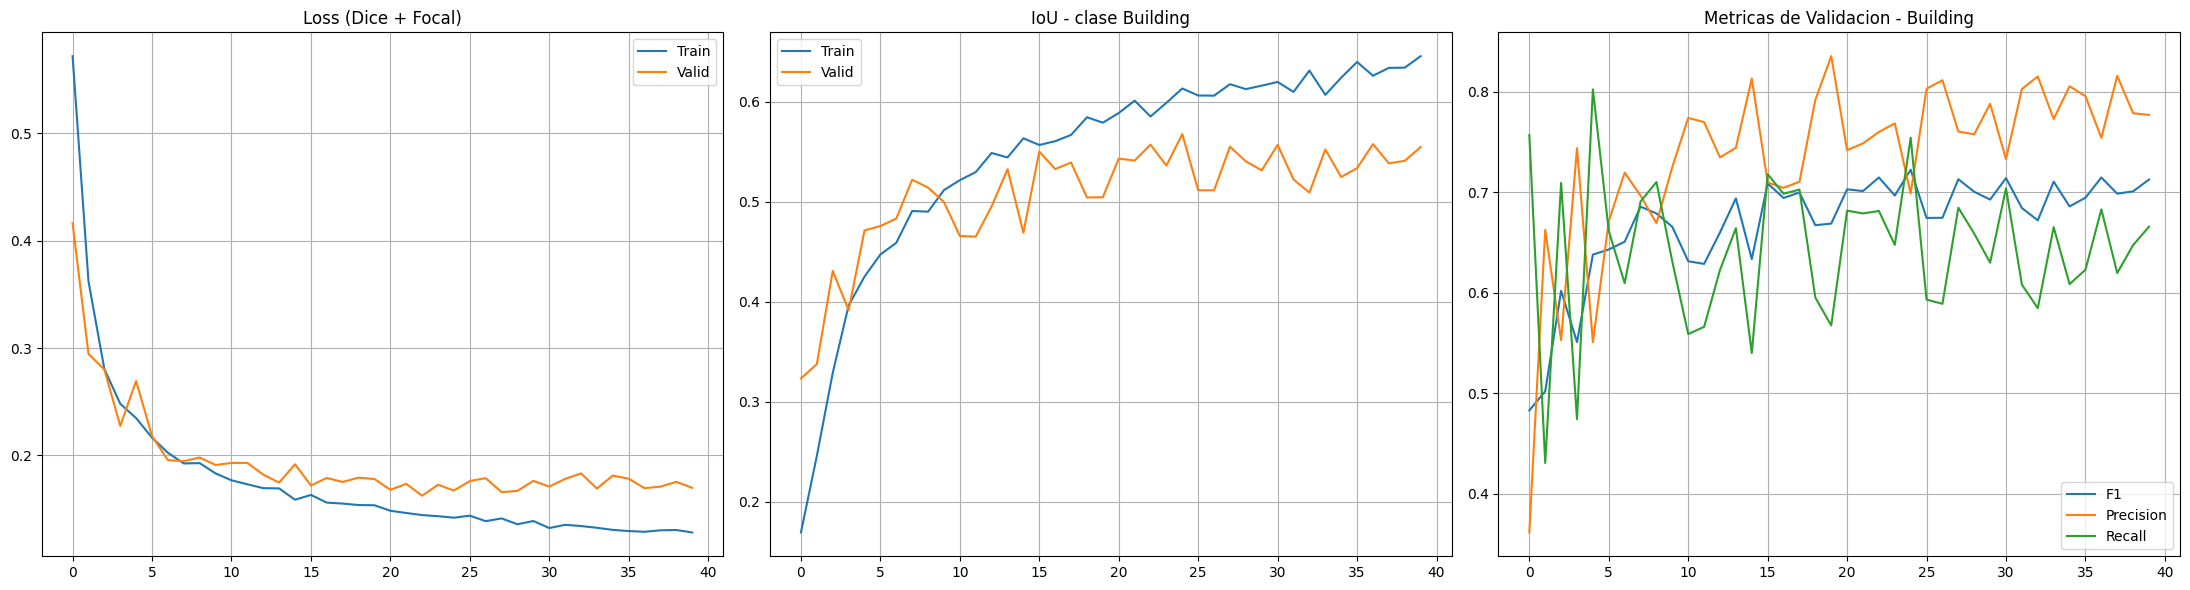

In [13]:
df_historial = pd.DataFrame(historial)

fig, ejes = plt.subplots(1, 3, figsize=(22, 6))
ejes[0].plot(df_historial['epoca'], df_historial['train_loss'], label='Train')
ejes[0].plot(df_historial['epoca'], df_historial['val_loss'], label='Valid')
ejes[0].set_title('Loss (Dice + Focal)'); ejes[0].legend(); ejes[0].grid()

ejes[1].plot(df_historial['epoca'], df_historial['train_iou_building'], label='Train')
ejes[1].plot(df_historial['epoca'], df_historial['val_iou_building'], label='Valid')
ejes[1].set_title('IoU - clase Building'); ejes[1].legend(); ejes[1].grid()

ejes[2].plot(df_historial['epoca'], df_historial['val_f1_building'], label='F1')
ejes[2].plot(df_historial['epoca'], df_historial['val_precision_building'], label='Precision')
ejes[2].plot(df_historial['epoca'], df_historial['val_recall_building'], label='Recall')
ejes[2].set_title('Metricas de Validacion - Building'); ejes[2].legend(); ejes[2].grid()

plt.tight_layout()
plt.savefig('curvas_entrenamiento_segformer_mit_b2.png')
plt.show()


In [14]:
# ============================================================
# TTA + EVALUACIÓN COMPLETA
# ============================================================

def predecir_con_tta(modelo, imagenes):
    variantes = [
        (imagenes, lambda z: z),
        (torch.flip(imagenes, dims=[3]), lambda z: torch.flip(z, dims=[3])),
        (torch.flip(imagenes, dims=[2]), lambda z: torch.flip(z, dims=[2])),
        (torch.flip(imagenes, dims=[2, 3]), lambda z: torch.flip(z, dims=[2, 3])),
    ]
    acumulado = None
    for entrada, deshacer in variantes:
        logits = modelo(entrada)
        logits = deshacer(logits)
        acumulado = logits if acumulado is None else acumulado + logits
    return acumulado / len(variantes)


def _agregar_stats_multiclase(lista, pred, verdad):
    tp, fp, fn, tn = smp.metrics.get_stats(
        pred, verdad, mode="multiclass", num_classes=NUM_CLASES
    )
    lista["tp"].append(tp)
    lista["fp"].append(fp)
    lista["fn"].append(fn)
    lista["tn"].append(tn)


def evaluar_general(modelo, cargador, usar_tta=False, dispositivo=DISPOSITIVO):
    modelo.eval()
    stats = {"tp": [], "fp": [], "fn": [], "tn": []}

    with torch.no_grad():
        for imagenes, mascaras in tqdm(
            cargador,
            desc="GENERAL + TTA" if usar_tta else "GENERAL sin TTA"
        ):
            imagenes = imagenes.to(dispositivo).float()
            verdad = torch.argmax(mascaras.to(dispositivo).float(), dim=1)

            logits = (
                predecir_con_tta(modelo, imagenes)
                if usar_tta else modelo(imagenes)
            )
            pred = torch.argmax(logits, dim=1)

            _agregar_stats_multiclase(stats, pred, verdad)

    tp = torch.cat(stats["tp"])
    fp = torch.cat(stats["fp"])
    fn = torch.cat(stats["fn"])
    tn = torch.cat(stats["tn"])

    return {
        "Accuracy_Global": smp.metrics.accuracy(
            tp, fp, fn, tn, reduction="macro"
        ).item(),
        "IoU_Global": smp.metrics.iou_score(
            tp, fp, fn, tn, reduction="macro"
        ).item(),
        "F1_Global": smp.metrics.f1_score(
            tp, fp, fn, tn, reduction="macro"
        ).item(),
        "Precision_Global": smp.metrics.precision(
            tp, fp, fn, tn, reduction="macro"
        ).item(),
        "Recall_Global": smp.metrics.recall(
            tp, fp, fn, tn, reduction="macro"
        ).item(),
    }


def evaluar_building(modelo, cargador, threshold=0.5, usar_tta=False,
                     dispositivo=DISPOSITIVO):
    modelo.eval()
    tp_list, fp_list, fn_list, tn_list = [], [], [], []

    with torch.no_grad():
        for imagenes, mascaras in tqdm(
            cargador,
            desc="BUILDING + TTA" if usar_tta else "BUILDING sin TTA"
        ):
            imagenes = imagenes.to(dispositivo).float()
            verdad = torch.argmax(mascaras.to(dispositivo).float(), dim=1)

            logits = (
                predecir_con_tta(modelo, imagenes)
                if usar_tta else modelo(imagenes)
            )

            prob_building = torch.softmax(logits, dim=1)[:, 1]
            pred_building = (prob_building >= threshold).long()
            true_building = (verdad == 1).long()

            tp, fp, fn, tn = smp.metrics.get_stats(
                pred_building,
                true_building,
                mode="binary"
            )

            tp_list.append(tp)
            fp_list.append(fp)
            fn_list.append(fn)
            tn_list.append(tn)

    tp = torch.cat(tp_list)
    fp = torch.cat(fp_list)
    fn = torch.cat(fn_list)
    tn = torch.cat(tn_list)

    return {
        "Accuracy_Building": smp.metrics.accuracy(
            tp, fp, fn, tn, reduction="micro"
        ).item(),
        "IoU_Building": smp.metrics.iou_score(
            tp, fp, fn, tn, reduction="micro"
        ).item(),
        "F1_Building": smp.metrics.f1_score(
            tp, fp, fn, tn, reduction="micro"
        ).item(),
        "Precision_Building": smp.metrics.precision(
            tp, fp, fn, tn, reduction="micro"
        ).item(),
        "Recall_Building": smp.metrics.recall(
            tp, fp, fn, tn, reduction="micro"
        ).item(),
        "Threshold": float(threshold),
    }


def evaluar_completo(modelo, cargador, threshold, usar_tta=False):
    resultado = {
        "Configuracion": "TEST con TTA" if usar_tta else "TEST sin TTA"
    }
    resultado.update(evaluar_general(
        modelo, cargador, usar_tta=usar_tta
    ))
    resultado.update(evaluar_building(
        modelo, cargador, threshold=threshold, usar_tta=usar_tta
    ))
    return resultado


In [15]:
# ============================================================
# CALIBRACIÓN DE THRESHOLD — VALIDATION ÚNICAMENTE
# ============================================================

def seleccionar_threshold_validation(modelo, cargador_val, usar_tta=True):
    filas = []

    for threshold in THRESHOLDS_VALIDACION:
        resultado = evaluar_building(
            modelo=modelo,
            cargador=cargador_val,
            threshold=float(threshold),
            usar_tta=usar_tta,
            dispositivo=DISPOSITIVO,
        )
        filas.append(resultado)

    df = pd.DataFrame(filas)
    idx = df["IoU_Building"].idxmax()
    threshold_optimo = float(df.loc[idx, "Threshold"])

    print("=" * 70)
    print("THRESHOLD SELECCIONADO EN VALIDATION")
    print("=" * 70)
    display(df.round(4))
    print(
        f"Threshold óptimo = {threshold_optimo:.2f} | "
        f"IoU Building Validation = {df.loc[idx, 'IoU_Building']:.4f}"
    )

    df.to_csv("threshold_validation_segformer_mit_b2_tiles256.csv", index=False)
    return threshold_optimo, df


THRESHOLD_OPTIMO, tabla_threshold = seleccionar_threshold_validation(
    modelo, cargador_val, usar_tta=True
)

print("\nEl threshold queda congelado para TEST:", THRESHOLD_OPTIMO)


BUILDING + TTA:   0%|          | 0/1 [00:00<?, ?it/s]

[ WARN:0@341.370] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@341.370] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@341.370] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@341.370] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@341.370] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@341.395] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@341.395] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@341.395] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) enco

BUILDING + TTA:   0%|          | 0/1 [00:00<?, ?it/s]

[ WARN:0@341.599] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@341.599] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@341.599] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@341.599] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@341.599] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@341.631] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@341.631] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@341.631] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) enco

BUILDING + TTA:   0%|          | 0/1 [00:00<?, ?it/s]

...

BUILDING + TTA:   0%|          | 0/1 [00:00<?, ?it/s]

[ WARN:0@343.078] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@343.078] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@343.078] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@343.078] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@343.078] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@343.103] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@343.103] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@343.103] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) enco

THRESHOLD SELECCIONADO EN VALIDATION


,Accuracy_Building,IoU_Building,F1_Building,Precision_Building,Recall_Building,Threshold
0,0.9155,0.5733,0.7288,0.7016,0.7582,0.30
1,0.9182,0.5747,0.7299,0.7225,0.7374,0.35
2,0.9202,0.5733,0.7288,0.7422,0.7160,0.40
3,0.9217,0.5708,0.7267,0.7611,0.6953,0.45
4,0.9221,0.5640,0.7212,0.7775,0.6726,0.50
5,0.9222,0.5557,0.7144,0.7937,0.6495,0.55
6,0.9225,0.5480,0.7080,0.8128,0.6272,0.60
7,0.9219,0.5358,0.6977,0.8298,0.6019,0.65
8,0.9208,0.5204,0.6846,0.8477,0.5741,0.70


Threshold óptimo = 0.35 | IoU Building Validation = 0.5747

El threshold queda congelado para TEST: 0.35


In [16]:
# ============================================================
# EVALUACIÓN FINAL EN TEST — SIN TTA VS TTA
# El threshold fue fijado previamente usando SOLO validation.
# ============================================================

modelo.load_state_dict(
    torch.load(
        "segformer_mit_b2_edificios_best.pth",
        map_location=DISPOSITIVO
    )
)
modelo.eval()

conjunto_test = DatasetEdificios(
    ruta_test_x, ruta_test_y,
    tam_crop=TAMANO_IMAGEN,
    sesgo_building=0.0,  # determinista en test
    intentos_crop=INTENTOS_CROP_SESGADO,
    aumentacion=aumentos_validacion(),
    preprocesamiento=preparar_preprocesamiento(funcion_preprocesamiento),
    rgb_clases=rgb_clases_seleccionadas,
)
cargador_test = DataLoader(
    conjunto_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

resultado_test_sin_tta = evaluar_completo(
    modelo, cargador_test,
    threshold=THRESHOLD_OPTIMO,
    usar_tta=False
)

resultado_test_tta = evaluar_completo(
    modelo, cargador_test,
    threshold=THRESHOLD_OPTIMO,
    usar_tta=True
)

tabla_test_final = pd.DataFrame(
    [resultado_test_sin_tta, resultado_test_tta]
)

display(tabla_test_final.round(4))
tabla_test_final.to_csv(
    "resultados_test_segformer_mit_b2_tiles256_tta.csv",
    index=False
)


GENERAL sin TTA:   0%|          | 0/3 [00:00<?, ?it/s]

[ WARN:0@343.443] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@343.444] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@343.444] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@343.444] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@343.444] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@343.470] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@343.470] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@343.470] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) enco

BUILDING sin TTA:   0%|          | 0/3 [00:00<?, ?it/s]

[ WARN:0@344.835] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@344.835] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@344.835] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@344.835] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@344.835] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@344.863] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@344.863] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@344.863] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) enco

GENERAL + TTA:   0%|          | 0/3 [00:00<?, ?it/s]

[ WARN:0@345.154] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@345.155] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@345.155] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@345.155] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@345.155] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@345.190] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@345.190] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@345.190] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) enco

BUILDING + TTA:   0%|          | 0/3 [00:00<?, ?it/s]

[ WARN:0@345.724] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@345.724] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@345.724] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@345.724] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@345.724] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@345.761] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@345.761] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@345.761] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) enco

,Configuracion,Accuracy_Global,IoU_Global,F1_Global,Precision_Global,Recall_Global,Accuracy_Building,IoU_Building,F1_Building,Precision_Building,Recall_Building,Threshold
0,TEST sin TTA,0.8771,0.7081,0.8205,0.8036,0.8430,0.8628,0.5512,0.7107,0.6162,0.8394,0.35
1,TEST con TTA,0.8790,0.7117,0.8232,0.8063,0.8457,0.8666,0.5616,0.7192,0.6230,0.8507,0.35


In [17]:
# FUNCIONES AUXILIARES PARA VISUALIZACIÓN E INFERENCIA ESPACIAL

def leer_rgb_test_original(conjunto, indice, tam=None):
    """Lee la imagen RGB original asociada al índice del conjunto."""
    if tam is None:
        tam = TAMANO_IMAGEN

    ruta = conjunto.rutas_imagenes[indice]
    imagen = cv2.imread(ruta, cv2.IMREAD_COLOR)
    if imagen is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    alto, ancho = imagen.shape[:2]

    # Para mantener correspondencia con el DatasetEdificios:
    # se toma el recorte central determinista de 256x256.
    if alto >= tam and ancho >= tam:
        y = (alto - tam) // 2
        x = (ancho - tam) // 2
        imagen = imagen[y:y + tam, x:x + tam]
    else:
        canvas = np.zeros((tam, tam, 3), dtype=np.uint8)
        h = min(alto, tam)
        w = min(ancho, tam)
        canvas[:h, :w] = imagen[:h, :w]
        imagen = canvas

    return imagen


def mejorar_contraste_rgb(imagen, p_low=2, p_high=98):
    """Realce visual 2-98 % por banda. No modifica el GeoTIFF de salida."""
    imagen = np.asarray(imagen)

    if imagen.ndim != 3 or imagen.shape[2] != 3:
        raise ValueError(
            f"Se esperaba una imagen RGB HxWx3 y se recibió {imagen.shape}."
        )

    if imagen.dtype == np.uint8:
        arr = imagen.astype(np.float32)
    else:
        arr = imagen.astype(np.float32)

    salida = np.zeros_like(arr, dtype=np.float32)

    for b in range(3):
        lo, hi = np.percentile(arr[:, :, b], [p_low, p_high])
        if hi <= lo:
            hi = lo + 1.0
        salida[:, :, b] = np.clip(
            (arr[:, :, b] - lo) / (hi - lo) * 255.0,
            0,
            255
        )

    return salida.astype(np.uint8)


def posiciones_ventanas_spaciales(height, width, tile_size=256, stride=192):
    """Genera ventanas que cubren toda la imagen, incluyendo los bordes."""
    if height <= 0 or width <= 0:
        raise ValueError("Las dimensiones del raster deben ser positivas.")
    if tile_size <= 0 or stride <= 0:
        raise ValueError("tile_size y stride deben ser mayores que cero.")

    ys = list(range(0, max(height - tile_size, 0) + 1, stride))
    xs = list(range(0, max(width - tile_size, 0) + 1, stride))

    if not ys or ys[-1] + tile_size < height:
        ys.append(max(height - tile_size, 0))
    if not xs or xs[-1] + tile_size < width:
        xs.append(max(width - tile_size, 0))

    return [(y, x) for y in ys for x in xs]




[ WARN:0@346.234] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@346.234] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@346.234] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@346.234] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@346.234] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@346.391] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@346.391] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@346.391] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) enco

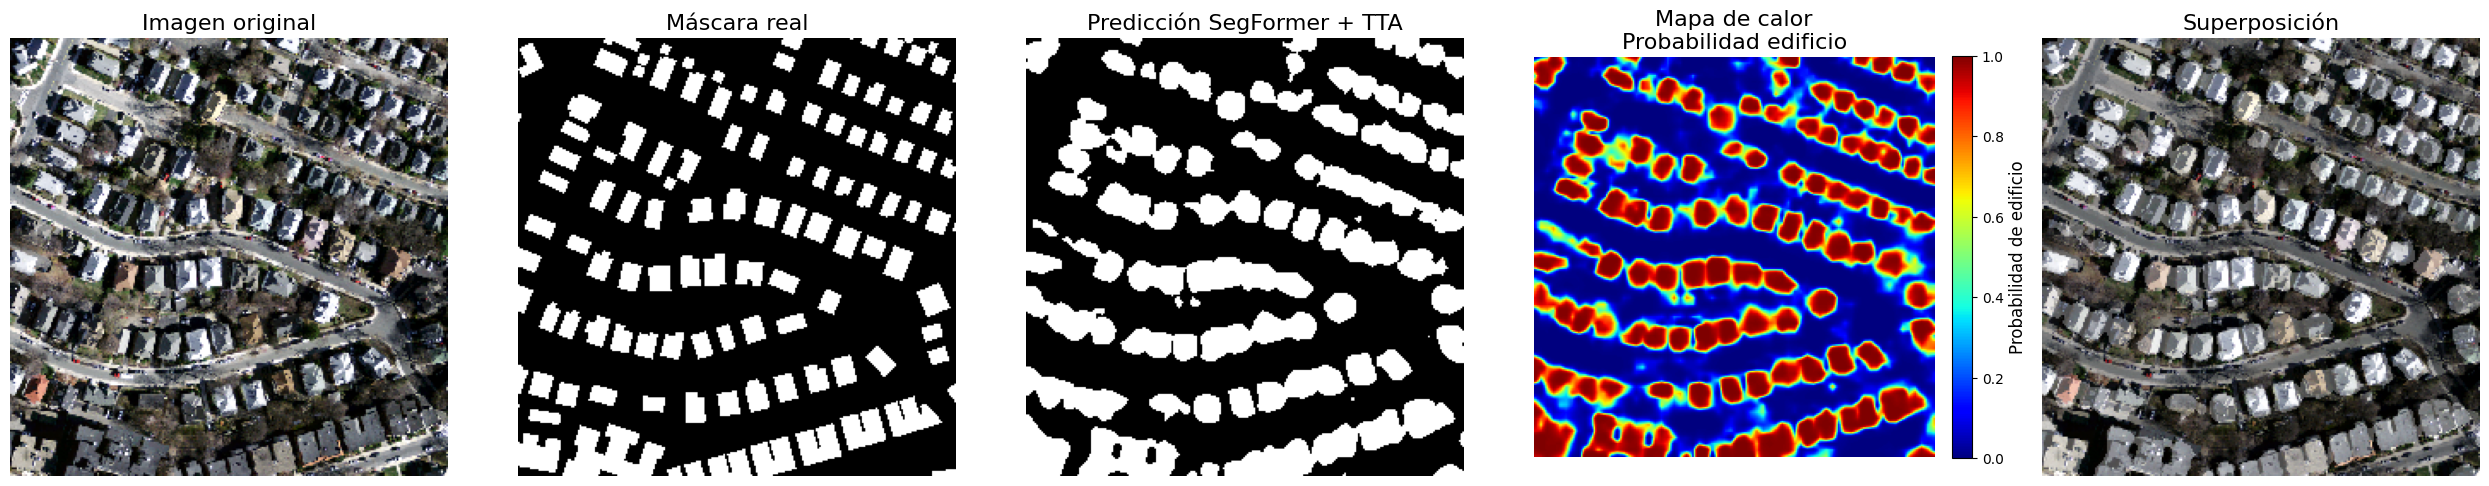

Índice de test seleccionado: 1
Archivo original: /kaggle/input/datasets/balraj98/massachusetts-buildings-dataset/tiff/test/22828990_15.tiff
Probabilidad máxima de edificio: 0.9999
Probabilidad media de edificio: 0.3616


In [18]:
# VISUALIZACIÓN DE TEST CON MAPA DE CALOR

def visualizar_test_con_heatmap(
    imagen_original,
    mascara_real,
    prediccion,
    probabilidad_building,
    superposicion,
    cmap="jet"
):
    """
    Muestra:
    1. Imagen RGB original
    2. Máscara real
    3. Predicción binaria
    4. Mapa de calor de probabilidad de edificio
    5. Superposición de la predicción sobre la imagen

    probabilidad_building debe estar en [0, 1].
    """
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))

    axes[0].imshow(imagen_original)
    axes[0].set_title("Imagen original", fontsize=16)

    axes[1].imshow(mascara_real)
    axes[1].set_title("Máscara real", fontsize=16)

    axes[2].imshow(prediccion)
    axes[2].set_title("Predicción SegFormer + TTA", fontsize=16)

    im = axes[3].imshow(
        probabilidad_building,
        cmap=cmap,
        vmin=0.0,
        vmax=1.0
    )
    axes[3].set_title("Mapa de calor\nProbabilidad edificio", fontsize=16)

    axes[4].imshow(superposicion)
    axes[4].set_title("Superposición", fontsize=16)

    for ax in axes:
        ax.axis("off")

    cbar = fig.colorbar(
        im,
        ax=axes[3],
        fraction=0.046,
        pad=0.04
    )
    cbar.set_label(
        "Probabilidad de edificio",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()


indice_aleatorio = random.randint(0, len(conjunto_test) - 1)

imagen, mascara_real_onehot = conjunto_test[indice_aleatorio]
tensor_x = torch.tensor(imagen).unsqueeze(0).to(DISPOSITIVO)

with torch.no_grad():
    logits = predecir_con_tta(modelo, tensor_x)

    # Probabilidad de la clase building.
    probabilidades = torch.softmax(logits, dim=1)
    probabilidad_building = (
        probabilidades[0, 1]
        .cpu()
        .numpy()
    )

    # Predicción final binaria/multiclase.
    prediccion = torch.argmax(
        logits.squeeze(0),
        dim=0
    ).cpu().numpy()


# Recuperar la imagen original RGB para visualización.
# Esto evita mostrar la imagen normalizada por ImageNet.

imagen_vis_original = leer_rgb_test_original(
    conjunto_test,
    indice_aleatorio,
    tam=TAMANO_IMAGEN
)

imagen_vis_original = mejorar_contraste_rgb(
    imagen_vis_original
)

# Máscara real.

mascara_real_vis = mascara_real_onehot.transpose(1, 2, 0)

mascara_real_rgb = colorear_segmentacion(
    decodificar_one_hot(mascara_real_vis),
    rgb_clases_seleccionadas
)

# Predicción coloreada.
mascara_predicha_rgb = colorear_segmentacion(
    prediccion,
    rgb_clases_seleccionadas
)


# Superposición.
superposicion = cv2.addWeighted(
    imagen_vis_original.astype(np.uint8),
    0.70,
    mascara_predicha_rgb.astype(np.uint8),
    0.30,
    0
)


# Mostrar resultados.
visualizar_test_con_heatmap(
    imagen_original=imagen_vis_original,
    mascara_real=mascara_real_rgb,
    prediccion=mascara_predicha_rgb,
    probabilidad_building=probabilidad_building,
    superposicion=superposicion,
)

print(f"Índice de test seleccionado: {indice_aleatorio}")
print(f"Archivo original: {conjunto_test.rutas_imagenes[indice_aleatorio]}")
print(
    f"Probabilidad máxima de edificio: "
    f"{probabilidad_building.max():.4f}"
)
print(
    f"Probabilidad media de edificio: "
    f"{probabilidad_building.mean():.4f}"
)


Inferencia espacial GeoTIFF:   0%|          | 0/64 [00:00<?, ?it/s]

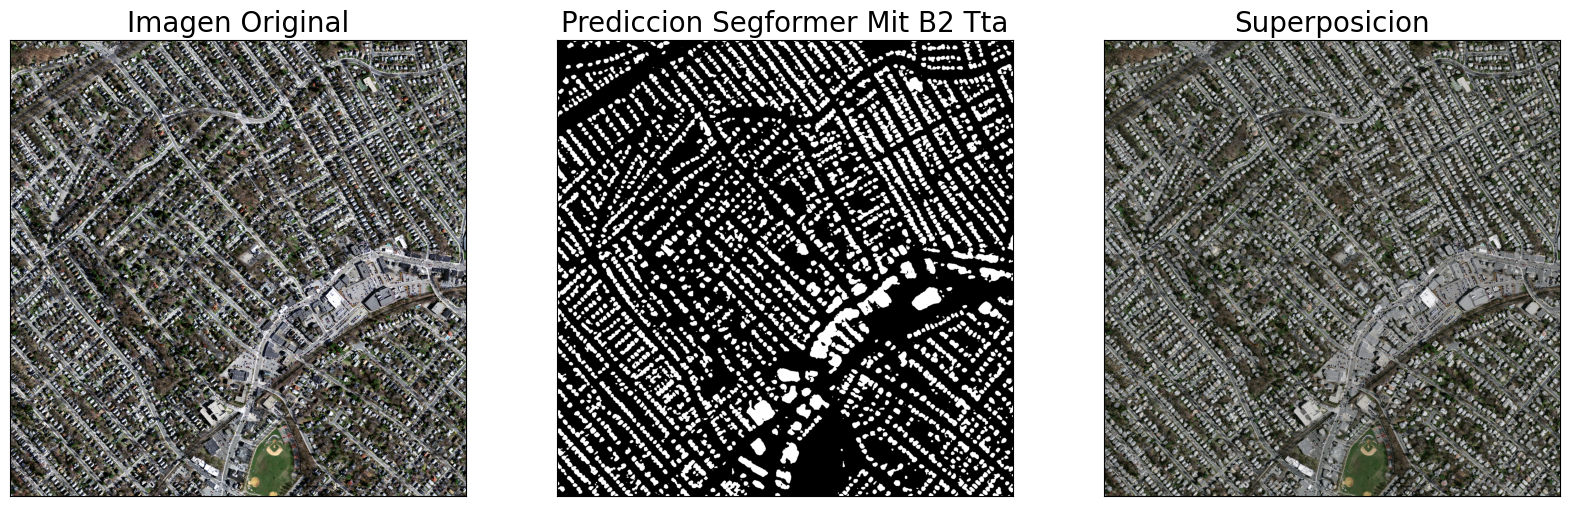

INFERENCIA GEOESPACIAL COMPLETADA
Entrada : /kaggle/input/datasets/balraj98/massachusetts-buildings-dataset/tiff/test/22828930_15.tiff
Máscara : prediccion_segformer_mit_b2_buildings.tif
Overlay : prediccion_segformer_mit_b2_overlay.tif
CRS     : EPSG:26986
Resolución: (1.0000000000000195, 0.9999999999999225)
Bounds  : BoundingBox(left=227486.4361739957, bottom=892271.0247782533, right=228986.43617399572, top=893771.0247782532)
Threshold: 0.35


In [19]:
# INFERENCIA SOBRE IMAGEN PROPIA
def convertir_rgb_a_uint8_para_modelo(arr_rgb):
    """
    Convierte el RGB leído del GeoTIFF a uint8.
    Para datos no uint8 se aplica un estiramiento independiente
    por banda entre los percentiles 2 y 98.
    """
    arr_rgb = np.asarray(arr_rgb)

    if arr_rgb.dtype == np.uint8:
        return arr_rgb

    arrf = arr_rgb.astype(np.float32)
    salida = np.zeros_like(arrf, dtype=np.float32)

    for b in range(arrf.shape[2]):
        lo, hi = np.percentile(arrf[:, :, b], [2, 98])
        if hi <= lo:
            hi = lo + 1.0
        salida[:, :, b] = np.clip(
            (arrf[:, :, b] - lo) / (hi - lo) * 255.0,
            0,
            255
        )

    return salida.astype(np.uint8)


def inferir_tile_segformer(tile_rgb, modelo, usar_tta=True):
    """
    Ejecuta inferencia para un tile RGB de 256x256.
    """
    if tile_rgb.shape[:2] != (TAMANO_IMAGEN, TAMANO_IMAGEN):
        raise ValueError(
            f"El tile debe ser {TAMANO_IMAGEN}x{TAMANO_IMAGEN}, "
            f"recibido: {tile_rgb.shape[:2]}"
        )

    preprocesar = preparar_preprocesamiento(funcion_preprocesamiento)

    dummy_mask = np.zeros(
        (TAMANO_IMAGEN, TAMANO_IMAGEN, NUM_CLASES),
        dtype=np.float32
    )

    procesado = preprocesar(
        image=tile_rgb,
        mask=dummy_mask
    )

    tensor = torch.from_numpy(
        procesado["image"]
    ).unsqueeze(0).to(DISPOSITIVO).float()

    with torch.no_grad():
        logits = (
            predecir_con_tta(modelo, tensor)
            if usar_tta else modelo(tensor)
        )

        prob_building = torch.softmax(
            logits, dim=1
        )[0, 1].cpu().numpy()

    return prob_building


def predecir_geotiff_propio(
    ruta_entrada,
    ruta_salida_mascara,
    modelo,
    threshold,
    ruta_salida_overlay=None,
    tile_size=256,
    stride=192,
    usar_tta=True
):
    """
    Inferencia sobre un GeoTIFF completo.

    Conserva del raster de entrada:
    - CRS
    - transform
    - resolución
    - ancho
    - alto

    Genera:
    1) máscara binaria GeoTIFF (0 background / 1 building)
    2) opcionalmente un overlay RGB GeoTIFF georreferenciado
    """

    with rasterio.open(ruta_entrada) as src:
        if src.count < 1:
            raise ValueError("El GeoTIFF no contiene bandas.")

        height = src.height
        width = src.width

        crs_entrada = src.crs
        transform_entrada = src.transform
        profile_entrada = src.profile.copy()
        bounds_entrada = src.bounds
        resolucion_entrada = src.res

        if src.count >= 3:
            arr = src.read([1, 2, 3])
        else:
            b = src.read(1)
            arr = np.stack([b, b, b], axis=0)

        arr = np.transpose(arr, (1, 2, 0))
        arr_uint8 = convertir_rgb_a_uint8_para_modelo(arr)

    posiciones = posiciones_ventanas_spaciales(
        height,
        width,
        tile_size=tile_size,
        stride=stride
    )

    acumulado = np.zeros((height, width), dtype=np.float32)
    pesos = np.zeros((height, width), dtype=np.float32)

    modelo.eval()

    for y, x in tqdm(
        posiciones,
        desc="Inferencia espacial GeoTIFF"
    ):
        y2 = min(y + tile_size, height)
        x2 = min(x + tile_size, width)

        tile = arr_uint8[y:y2, x:x2]

        tile_padded = np.zeros(
            (tile_size, tile_size, 3),
            dtype=np.uint8
        )

        tile_padded[
            :tile.shape[0],
            :tile.shape[1]
        ] = tile

        prob_tile = inferir_tile_segformer(
            tile_padded,
            modelo,
            usar_tta=usar_tta
        )

        prob_tile = prob_tile[
            :tile.shape[0],
            :tile.shape[1]
        ]

        acumulado[y:y2, x:x2] += prob_tile
        pesos[y:y2, x:x2] += 1.0

    probabilidad = acumulado / np.maximum(pesos, 1e-7)

    mascara = (
        probabilidad >= float(threshold)
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Guardar máscara GeoTIFF
    # --------------------------------------------------------
    profile_mascara = profile_entrada.copy()
    profile_mascara.update(
        driver="GTiff",
        dtype="uint8",
        count=1,
        compress="deflate",
        predictor=2,
        nodata=0,
        width=width,
        height=height,
        crs=crs_entrada,
        transform=transform_entrada
    )

    with rasterio.open(
        ruta_salida_mascara,
        "w",
        **profile_mascara
    ) as dst:
        dst.write(mascara, 1)
        dst.set_band_description(
            1,
            "Building mask"
        )


    # Crear y guardar overlay RGB GeoTIFF

    overlay_rgb = arr_uint8.copy()

    color_building = np.array(
        rgb_clases_seleccionadas[1],
        dtype=np.uint8
    )

    alpha = 0.35
    mask_bool = mascara == 1

    overlay_rgb[mask_bool] = (
        (1 - alpha) * overlay_rgb[mask_bool]
        + alpha * color_building
    ).astype(np.uint8)

    if ruta_salida_overlay is not None:
        profile_overlay = profile_entrada.copy()
        profile_overlay.update(
            driver="GTiff",
            dtype="uint8",
            count=3,
            compress="deflate",
            predictor=2,
            nodata=None,
            width=width,
            height=height,
            crs=crs_entrada,
            transform=transform_entrada
        )

        with rasterio.open(
            ruta_salida_overlay,
            "w",
            **profile_overlay
        ) as dst:
            dst.write(
                np.transpose(overlay_rgb, (2, 0, 1))
            )
            dst.set_band_description(1, "Red")
            dst.set_band_description(2, "Green")
            dst.set_band_description(3, "Blue")

    # Validación espacial
    with rasterio.open(ruta_salida_mascara) as salida:
        assert salida.crs == crs_entrada, (
            "El CRS de salida no coincide con el de entrada."
        )
        assert salida.transform == transform_entrada, (
            "El transform de salida no coincide con el de entrada."
        )
        assert (salida.height, salida.width) == (
            height,
            width
        ), "Las dimensiones espaciales de salida cambiaron."
        assert salida.res == resolucion_entrada, (
            "La resolución espacial de salida cambió."
        )
        assert salida.bounds == bounds_entrada, (
            "Los bounds de salida cambiaron."
        )

    return {
        "imagen_rgb": arr_uint8,
        "mascara": mascara,
        "probabilidad": probabilidad,
        "overlay_rgb": overlay_rgb,
        "crs": crs_entrada,
        "transform": transform_entrada,
        "bounds": bounds_entrada,
        "resolucion": resolucion_entrada,
    }

# EJECUCIÓN SOBRE IMAGEN PROPIA

ruta_imagen_propia = (
    "/kaggle/input/datasets/balraj98/"
    "massachusetts-buildings-dataset/tiff/test/22828930_15.tiff"
)

ruta_salida_mascara = (
    "prediccion_segformer_mit_b2_buildings.tif"
)

ruta_salida_overlay = (
    "prediccion_segformer_mit_b2_overlay.tif"
)

if os.path.exists(ruta_imagen_propia):

    resultado_propio = predecir_geotiff_propio(
        ruta_entrada=ruta_imagen_propia,
        ruta_salida_mascara=ruta_salida_mascara,
        ruta_salida_overlay=ruta_salida_overlay,
        modelo=modelo,
        threshold=THRESHOLD_OPTIMO,
        tile_size=TAMANO_IMAGEN,
        stride=192,
        usar_tta=True,
    )

    visualizar(
        imagen_original=mejorar_contraste_rgb(
            resultado_propio["imagen_rgb"]
        ),
        prediccion_segformer_mit_b2_tta=colorear_segmentacion(
            resultado_propio["mascara"],
            rgb_clases_seleccionadas
        ),
        superposicion=resultado_propio["overlay_rgb"],
    )

    print("=" * 70)
    print("INFERENCIA GEOESPACIAL COMPLETADA")
    print("=" * 70)
    print(f"Entrada : {ruta_imagen_propia}")
    print(f"Máscara : {ruta_salida_mascara}")
    print(f"Overlay : {ruta_salida_overlay}")
    print(f"CRS     : {resultado_propio['crs']}")
    print(f"Resolución: {resultado_propio['resolucion']}")
    print(f"Bounds  : {resultado_propio['bounds']}")
    print(f"Threshold: {THRESHOLD_OPTIMO:.2f}")

else:
    print(
        f"No se encontró '{ruta_imagen_propia}'. "
        "Ajusta la ruta a tu GeoTIFF."
    )


In [20]:

# AUDITORÍA FINAL DE FUNCIONES, VARIABLES Y ARQUITECTURA

funciones_clave = [
    "fijar_semilla", "DatasetEdificios", "preparar_preprocesamiento",
    "ejecutar_epoca", "predecir_con_tta", "evaluar_general",
    "evaluar_building", "evaluar_completo",
    "seleccionar_threshold_validation",
    "leer_rgb_test_original", "mejorar_contraste_rgb",
    "visualizar_test_con_heatmap", "inferir_tile_segformer", "posiciones_ventanas_spaciales", "predecir_geotiff_propio",
]

variables_clave = [
    "SEMILLA", "DISPOSITIVO", "CODIFICADOR", "PESOS_CODIFICADOR", "NUM_WORKERS",
    "NUM_CLASES", "TAMANO_IMAGEN", "BATCH_SIZE", "EPOCAS",
    "LEARNING_RATE", "WEIGHT_DECAY", "T_MAX", "T_MAX_SCHEDULER",
    "PACIENCIA_EARLY_STOPPING", "MEJORES_K_CHECKPOINTS",
    "THRESHOLDS_VALIDACION",
]

faltantes_funciones = [n for n in funciones_clave if n not in globals()]
faltantes_variables = [n for n in variables_clave if n not in globals()]

if faltantes_funciones:
    raise NameError("Funciones faltantes: " + ", ".join(faltantes_funciones))
if faltantes_variables:
    raise NameError("Variables faltantes: " + ", ".join(faltantes_variables))

assert ARCHITECTURE == "SegFormer"
assert CODIFICADOR == "mit_b2"
assert isinstance(modelo, smp.Segformer)
assert T_MAX == 80
assert T_MAX_SCHEDULER == 80
assert BATCH_SIZE == 4
assert NUM_WORKERS == 0

assert hasattr(smp, "Segformer")
assert "mit_b2" in smp.encoders.get_encoder_names()

print("=" * 70)
print("AUDITORÍA FINAL: OK")
print(f"Arquitectura: {ARCHITECTURE}")
print(f"Encoder: {CODIFICADOR}")
print(f"T_max scheduler: {T_MAX_SCHEDULER}")
print("=" * 70)

assert "leer_rgb_test_original" in globals()
assert "mejorar_contraste_rgb" in globals()
assert "posiciones_ventanas_spaciales" in globals()

assert "visualizar_test_con_heatmap" in globals()


AUDITORÍA FINAL: OK
Arquitectura: SegFormer
Encoder: mit_b2
T_max scheduler: 80
